In [1]:
import pandas as pd
import numpy as np
from pathlib import Path 

np.random.seed(42)
frequency = 64
path = Path(f"data/raw/dreamt/data_{frequency}Hz")

COLS_TO_DROP = [
    "TIMESTAMP",
    "IBI",
    "Obstructive_Apnea",
    "Central_Apnea",
    "Hypopnea",
    "Multiple_Events",
]
nb_patients = 25
X_all_patients = []
y_all_patients = []
patient_file_list = [f for f in path.iterdir() if f.is_file()]
for patient_id in range(nb_patients):
    patient_file = patient_file_list.pop() 
    df = pd.read_csv(patient_file)
    df = df.drop(
                columns=COLS_TO_DROP
            )
    df = df[~df["Sleep_Stage"].isin(["Missing","P"])]    
    y_all_patients.append(df.Sleep_Stage.to_numpy())
    X_all_patients.append(df.drop(columns=["Sleep_Stage"]).to_numpy())


In [2]:
WINDOWS_SEC = 30
FS = 64

window_samples = FS * WINDOWS_SEC

X_bvp_patients = []
X_acc_patients = []
X_eda_temp_patients = []
X_hr_patients = []
y_patients = []

for patient in range(len(X_all_patients)):
    X_bvp = []
    X_acc = []
    X_eda_temp = []
    X_hr = []
    y = []
    data = X_all_patients[patient]
    T = data.shape[0]
    n_windows = T // window_samples
    for i in range(n_windows):
        start = i * window_samples
        end = start + window_samples
        # 1920, 
        X_bvp.append(data[start:end,0])
        # 960
        X_acc.append(data[start:end:2, 1:4])
        # 120
        X_eda_temp.append(data[start:end:16, 4:6])
        # 30
        X_hr.append(data[start:end:64, 6])
        #1
        y.append(y_all_patients[patient][start])
    
    X_bvp_patients.append(np.stack(X_bvp))
    X_acc_patients.append(np.stack(X_acc))
    X_hr_patients.append(np.stack(X_hr))
    X_eda_temp_patients.append(np.stack(X_eda_temp))
    y_patients.append(np.array(y))
        


In [3]:
X_bvp_train = []
X_bvp_test = []

X_acc_train = []
X_acc_test = []

X_eda_temp_train = []
X_eda_temp_test = []

X_hr_train = []
X_hr_test = []

y_train = []
y_test = []

test_size = 0.2

test_patients = np.random.choice(nb_patients, size= int(test_size * nb_patients), replace=False)

for patient in range(nb_patients):
    if patient not in test_patients:
        X_bvp_train.append(X_bvp_patients[patient])
        X_acc_train.append(X_acc_patients[patient])
        X_eda_temp_train.append(X_eda_temp_patients[patient])
        X_hr_train.append(X_hr_patients[patient])
        y_train.append(y_patients[patient])

    else:
        X_bvp_test.append(X_bvp_patients[patient])
        X_acc_test.append(X_acc_patients[patient])
        X_eda_temp_test.append(X_eda_temp_patients[patient])
        X_hr_test.append(X_hr_patients[patient])
        y_test.append(y_patients[patient])



X_bvp_train =np.concatenate(X_bvp_train)
X_bvp_test =np.concatenate(X_bvp_test)

X_acc_train =np.concatenate(X_acc_train)
X_acc_test =np.concatenate(X_acc_test)

X_eda_temp_train =np.concatenate(X_eda_temp_train)
X_eda_temp_test =np.concatenate(X_eda_temp_test)

X_hr_train =np.concatenate(X_hr_train)
X_hr_test =np.concatenate(X_hr_test)

y_train = np.concatenate(y_train)
y_test = np.concatenate(y_test)

(1920,)


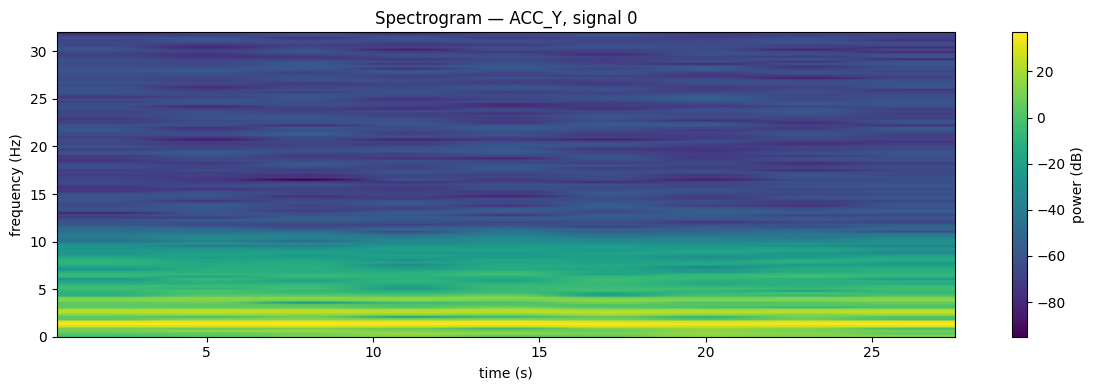

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.mlab import window_hanning 

example = X_bvp_train[:1000]  # shape (100, 960, 3)
fs = 64
channel = 1

# pick one signal and one channel
signal = example[9, :]  # shape (960,)
signal = np.squeeze(signal)
print(signal.shape)
fig, ax = plt.subplots(figsize=(12, 4))
ax.specgram(signal, NFFT=256, Fs=fs, noverlap=64, cmap='viridis', scale="dB", window=window_hanning)
ax.set_title(f'Spectrogram — ACC_{"XYZ"[channel]}, signal 0')
ax.set_xlabel('time (s)')
ax.set_ylabel('frequency (Hz)')
plt.colorbar(ax.images[0], ax=ax, label='power (dB)')
plt.tight_layout()
plt.show()

In [4]:
X_bvp_train = np.expand_dims(X_bvp_train, axis=1)
X_eda_temp_train = np.permute_dims(X_eda_temp_train, axes=[0,2,1])
X_acc_train = np.permute_dims(X_acc_train, axes=[0,2,1])
X_bvp_test      = np.expand_dims(X_bvp_test, axis=1)
X_eda_temp_test = np.permute_dims(X_eda_temp_test, axes=[0,2,1])
X_acc_test      = np.permute_dims(X_acc_test, axes=[0,2,1])

In [5]:
from sklearn.preprocessing import LabelEncoder

lb = LabelEncoder()
y_train_encoded = lb.fit_transform(y_train)
y_test_encoded = lb.transform(y_test)

y_train_encoded

array([4, 4, 4, ..., 1, 1, 1], shape=(16253,))

In [7]:
lb.classes_ 

array(['N1', 'N2', 'N3', 'R', 'W'], dtype='<U2')

In [33]:

import torch 
import torch.nn as nn 


class Residual(nn.Module):
    def __init__(self, input_size, hidden_size, kernel_size = 5, dilation_depth = 3):
        super().__init__()
        self.blocks = nn.ModuleList()
        original_input_size = input_size
        for i in range(dilation_depth): 
            dilation = 2 ** i 
            self.blocks.append(nn.Sequential(
                nn.ZeroPad2d(((kernel_size - 1) * dilation, 0, 0, 0)),
                nn.Conv2d(input_size, hidden_size, kernel_size=(1, kernel_size), dilation=(1, dilation)),
                nn.BatchNorm2d(hidden_size),
                nn.ReLU()
                ))
          
            input_size = hidden_size

        self.drop_out = nn.Dropout(0.5)

        self.align = nn.Conv2d(original_input_size, hidden_size, 1)  \
                if original_input_size != hidden_size else nn.Identity()
 


    def forward(self, input):
        x = input 
        for block in self.blocks:
            x = block(x)

        x = self.drop_out(x)

        return self.align(input) + x 
    


class MultiTCNBVPACC(nn.Module):
    def __init__(self):
        super().__init__()
        self.bc_bvp = nn.BatchNorm2d(1)
        self.bc_acc = nn.BatchNorm2d(3)

        self.bvp_block = Residual(input_size=1, hidden_size=32, dilation_depth=3)
        self.acc_block = Residual(input_size=3, hidden_size=32, dilation_depth=3)

        self.fc = nn.Sequential(
            nn.LazyLinear(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 5),

        ) 

        self.init_weights()

    def init_weights(self):
        for layer in self.modules():
            if isinstance(layer, (nn.Conv2d)):
                nn.init.kaiming_normal_(layer.weight)
                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)
            
    def forward(self, x_bvp, x_acc):
        out_bvp = self.bc_bvp(x_bvp)
        out_acc = self.bc_acc(x_acc)
        out_bvp = self.bvp_block(out_bvp)
        out_acc = self.acc_block(out_acc)

        out_bvp = out_bvp.mean(dim=(-2,-1))
        out_acc = out_acc.mean(dim=(-2,-1))
        merged = torch.cat([out_bvp, out_acc], dim=1)
        # out = merged.flatten(1)
        
        return self.fc(merged)
    
class MultiTCNHRACC(nn.Module):
    def __init__(self):
        super().__init__()
        self.bc_acc = nn.BatchNorm2d(3)

        self.acc_block = Residual(input_size=3, hidden_size=128, dilation_depth=5)
        
        self.fc = nn.Sequential(
            nn.LazyLinear(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 5),

        ) 
        self.init_weights()

    def init_weights(self):
        for layer in self.modules():
            if isinstance(layer, (nn.Conv2d)):
                nn.init.kaiming_normal_(layer.weight)
                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)
            
    def forward(self, x_acc, x_hr):
        out_acc = self.bc_acc(x_acc)
        out_acc = self.acc_block(out_acc)
        hr_avg =  x_hr.mean(dim=1, keepdim=True)
        # torch.mean(x_hr, dim=1, keepdim=True)
        hr_std = x_hr.std(dim=1, keepdim=True) 
        flattened_acc = out_acc.flatten(start_dim = 1)
        merged = torch.cat([hr_avg, hr_std, flattened_acc], dim=1)
        
        return self.fc(merged)

In [7]:
def mask_spectrogram(X, P_T = 0.2, P_F = 0.1, W_T = 5, W_F = 2):
    n_channels, n_freq, n_frames = X.shape
    T_num = int(P_T * n_frames) // W_T
    F_num = int(P_F * n_freq) // W_F
    if torch.rand(1).item() > 0.8:
            return X
    
    M = torch.zeros((n_channels, n_freq, n_frames))
    T_indices = np.random.choice(n_frames - W_T, size=T_num, replace=False)
    F_indices = np.random.choice(n_freq - W_F, size=F_num, replace=False)
    for T in T_indices:
                M[:,:, T:T+W_T] = 1
    for F in F_indices:
                M[:,F:F+W_F,:] = 1

    return X * (1 - M)


In [8]:
from torch.utils.data import Dataset, DataLoader

class DreamtDatasetBVP_ACC(Dataset):
    def __init__(self, X_bvp, X_acc, y, n_fft_bvp, n_fft_acc):
        self.X_bvp = X_bvp  # (N, 1, 1920)
        self.X_acc = X_acc  # (N, 3, 960)
        self.y = y
        self.n_fft_bvp = n_fft_bvp 
        self.n_fft_acc = n_fft_acc
        self.window_bvp = torch.hann_window(n_fft_bvp)
        self.window_acc = torch.hann_window(n_fft_acc)

    def __getitem__(self, index):
        x_bvp = self.X_bvp[index] #(, 1920)
        x_acc = self.X_acc[index]  # (3, 960)
        bvp_sfft = torch.stft(
            x_bvp,
            n_fft = self.n_fft_bvp,
            hop_length=self.n_fft_bvp // 2,
            window = self.window_bvp,
            onesided = True, 
            center = False, 
            normalized= True, 
            return_complex= True, 
        ).abs() ** 2 
        bvp_sfft = 10 * torch.log10(bvp_sfft + 1e-8)
        
        acc_stft = torch.stft(
            x_acc,
            n_fft=self.n_fft_acc,
            hop_length=self.n_fft_acc // 2,
            window=self.window_acc,
            onesided=True,
            center= False,
            normalized=True,
            return_complex=True
        ).abs() ** 2  # (3, n_freqs, n_frames) (,59)
        acc_stft = 10 * torch.log10(acc_stft + 1e-8)
        return bvp_sfft, acc_stft, self.y[index]

    def __len__(self):
        return len(self.X_acc)
    

class DreamtDatasetHR_ACC(Dataset):
    def __init__(self, X_hr, X_acc, y, n_fft_acc):
        self.X_hr = X_hr  
        self.X_acc = X_acc  # (N, 3, 960)
        self.y = y
        self.n_fft_acc = n_fft_acc
        self.window_acc = torch.hann_window(n_fft_acc)

    def __getitem__(self, index):
        x_hr = self.X_hr[index] #(, 1920)
        x_acc = self.X_acc[index]  # (3, 960)        
        acc_stft = torch.stft(
            x_acc,
            n_fft=self.n_fft_acc,
            hop_length=self.n_fft_acc // 2,
            window=self.window_acc,
            onesided=True,
            center= False,
            normalized=True,
            return_complex=True
        ).abs() ** 2  # (3, n_freqs, n_frames) (,59)
        acc_stft = 10 * torch.log10(acc_stft + 1e-8)
        return x_hr, acc_stft, self.y[index]

    def __len__(self):
        return len(self.X_acc)
    

n_fft_bvp = 64 
n_fft_acc = 32 

X_bvp_train      = torch.FloatTensor(X_bvp_train)
X_hr_train      = torch.FloatTensor(X_hr_train)
X_acc_train      = torch.FloatTensor(X_acc_train)
y_train_encoded  = torch.LongTensor(y_train_encoded)  

train_ds = DreamtDatasetHR_ACC(X_hr_train, X_acc_train, y_train_encoded, n_fft_acc=n_fft_acc)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

In [9]:
from sklearn.utils.class_weight import compute_class_weight

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

classes = np.unique(y_train_encoded.numpy())
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_encoded.numpy())
weights = torch.FloatTensor(weights).to(DEVICE)


criterion = nn.CrossEntropyLoss(weight=weights, reduction="sum")

In [34]:
from tqdm import tqdm


X_bvp_test      = torch.FloatTensor(X_bvp_test)
X_hr_test      = torch.FloatTensor(X_hr_test)
X_acc_test       = torch.FloatTensor(X_acc_test)

test_ds = DreamtDatasetHR_ACC(X_hr_test, X_acc_test, y_test_encoded, n_fft_acc)
test_dl = DataLoader(test_ds, batch_size=1024)


def train_model(model, train_dl, epochs, weights= None, lr=0.001, device=torch.device("cpu")):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    if weights is None:
        criterion = nn.CrossEntropyLoss(reduction="sum")
    else: 
        criterion = nn.CrossEntropyLoss(weight=weights, reduction="sum")
    for epoch in tqdm(range(epochs)):
        model.train()
        empirical_risk = 0.0
        for x_hr, x_acc, y in train_dl:
            x_hr = x_hr.to(device)
            x_acc = x_acc.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            pred = model(x_acc,x_hr)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            empirical_risk += loss.item()

        empirical_risk /= len(train_dl.dataset)
        print("Train loss: %.3f" % (empirical_risk))
        
def test_model(model, test_dl, device=torch.device("cpu")):
    criterion = nn.CrossEntropyLoss(reduction="sum")
    model.eval()
    generalization_error = 0.0
    correct = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x_hr, x_acc, y in test_dl:
            x_hr = x_hr.to(device)
            x_acc = x_acc.to(device)
            y = y.to(device)
            logits = model(x_acc,x_hr)
            loss = criterion(logits, y)
            pred = torch.argmax(logits, dim=1)
            correct += (pred == y).sum().item()
            generalization_error += loss.item()
            all_preds.append(pred.cpu())
            all_targets.append(y.cpu())

        y_pred = torch.cat(all_preds).numpy()
        y_true = torch.cat(all_targets).numpy()
        generalization_error /= len(test_dl.dataset)
        accuracy = correct / len(test_dl.dataset)
        print(
            "Generalization Error: %.3f, Accuracy %.3f"
            % (generalization_error, accuracy)
        )

    return y_true, y_pred


model = MultiTCNHRACC()
model.to(DEVICE)

train_model(model, train_dl, weights=weights, epochs=50, device = DEVICE)


  2%|▏         | 1/50 [00:14<12:13, 14.96s/it]

Train loss: 2.004


  4%|▍         | 2/50 [00:30<12:00, 15.01s/it]

Train loss: 1.573


  6%|▌         | 3/50 [00:45<11:47, 15.06s/it]

...

Train loss: 1.200


 98%|█████████▊| 49/50 [12:23<00:15, 15.20s/it]

Train loss: 1.189


100%|██████████| 50/50 [12:38<00:00, 15.17s/it]

Train loss: 1.187


In [35]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

nrem_classes = [0,1,2,3]
merge_fn = np.vectorize(lambda x: 0 if x in nrem_classes else x) 

y_true, y_pred = test_model(model, test_dl, DEVICE)

y_true_merged = merge_fn(y_true)
y_pred_merged = merge_fn(y_pred)


print(classification_report(y_true_merged, y_pred_merged, target_names=["N","W"]))

Generalization Error: 1.695, Accuracy 0.131
              precision    recall  f1-score   support

           N       0.68      0.99      0.81      2707
           W       0.89      0.12      0.21      1413

    accuracy                           0.69      4120
   macro avg       0.79      0.55      0.51      4120
weighted avg       0.75      0.69      0.60      4120



In [36]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

nrem_classes = [0,1,2]
merge_fn = np.vectorize(lambda x: 0 if x in nrem_classes else x) 

y_true, y_pred = test_model(model, test_dl, DEVICE)

y_true_merged = merge_fn(y_true)
y_pred_merged = merge_fn(y_pred)


print(classification_report(y_true_merged, y_pred_merged, target_names=["N","R","W"]))

Generalization Error: 1.695, Accuracy 0.131
              precision    recall  f1-score   support

           N       0.56      0.37      0.44      2411
           R       0.09      0.75      0.17       296
           W       0.89      0.12      0.21      1413

    accuracy                           0.31      4120
   macro avg       0.51      0.41      0.27      4120
weighted avg       0.64      0.31      0.34      4120



ValueError: The number of FixedLocator locations (2), usually from a call to set_ticks, does not match the number of labels (3).

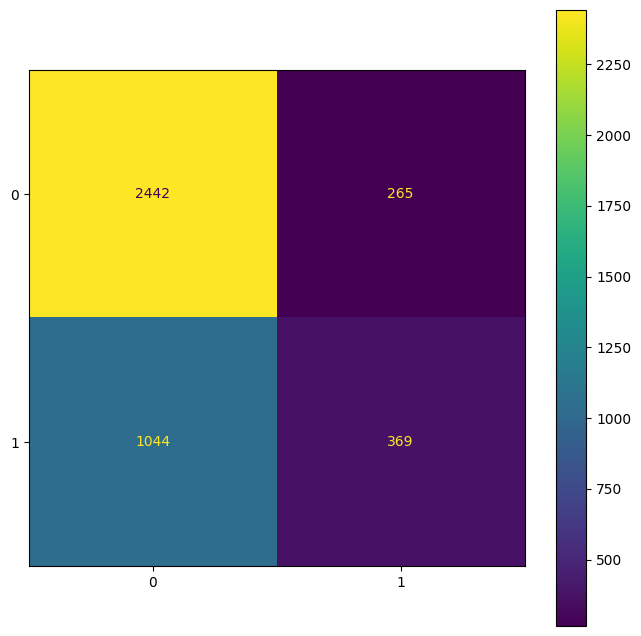

In [14]:
import matplotlib.pyplot as plt 

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(confusion_matrix(y_true_merged, y_pred_merged), display_labels=["N","R","W"]).plot(ax=ax)
# fig.savefig(f"reports/figures/confusion_matrix_U=25_C=3_M=TCN.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

In [ ]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

y_true, y_pred = test_model(model, test_dl, DEVICE)

print(classification_report(y_true, y_pred, target_names=lb.classes_))

Generalization Error: 2.059, Accuracy 0.334
              precision    recall  f1-score   support

          N1       0.08      0.26      0.12       293
          N2       0.52      0.40      0.45      2031
          N3       0.02      0.02      0.02       241
           R       0.18      0.14      0.16       552
           W       0.45      0.39      0.42      1156

    accuracy                           0.33      4273
   macro avg       0.25      0.24      0.23      4273
weighted avg       0.40      0.33      0.36      4273



In [ ]:
# import matplotlib.pyplot as plt 

# fig, ax = plt.subplots(figsize=(8, 8))
# ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=lb.classes_).plot(ax=ax)
# fig.savefig(f"reports/figures/confusion_matrix_U=25_C=5_M=TCN.png", dpi=150, bbox_inches="tight")
# plt.show()
# plt.close(fig)